# Model Comparison: Bayesian NNGP vs Bayesian Linear (with State FEs)

Fits two models on the full-US `zip_data_full.csv` dataset (all 48 contiguous states):
- **Spatial**: Bayesian NNGP (Vecchia/Matern-3/2) + covariates + state fixed effects
- **Linear**: Bayesian linear regression, same covariates + state fixed effects, no GP term

Two evaluation schemes:
1. **Within-year**: train on 80% of 2022 ZIPs, test on held-out 20%
2. **Cross-year**: train on all 2020 ZIPs, test on 2022 ZIPs (mimics real campaign use)

In [1]:
import sys
sys.path.insert(0, '../milestone4')

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
from pyproj import Transformer

from vecchia_spatial_regression import (
    build_model_data, fit_model, save_model_data, load_model_data,
    train_test_split, kernel_np, FULL_US_COVARIATES, lonlat_to_km,
)

In [2]:
df = pd.read_csv('zip_data_full.csv')
print(f'Loaded {len(df)} ZIP codes, {df["state"].nunique()} states')
print('Columns:', list(df.columns))
df.head()

Loaded 15776 ZIP codes, 50 states
Columns: ['ZIP_CODE', 'LOG_TRANSACTION_AMT_2020', 'LOG_TRANSACTION_AMT_2022', 'lat', 'lon', 'prop_college_degree_or_higher_18plus', 'log_income', 'log_population', 'log_contrib_2020', 'log_contrib_2022', 'election_2020', 'election_2022', 'election_diff', 'state']


,ZIP_CODE,LOG_TRANSACTION_AMT_2020,LOG_TRANSACTION_AMT_2022,lat,lon,prop_college_degree_or_higher_18plus,log_income,log_population,log_contrib_2020,log_contrib_2022,election_2020,election_2022,election_diff,state
0,1001,8.645059,6.838405,42.0702,-72.6227,0.345215,11.229793,9.740027,8.645059,6.838405,1,0,-1,MA
1,1002,11.812148,11.338191,42.3671,-72.4646,0.498242,11.167868,10.224048,11.812148,11.338191,1,0,-1,MA
2,1007,9.606496,8.426393,42.2751,-72.4110,0.437097,11.591043,9.643615,9.606496,8.426393,1,0,-1,MA
3,1013,8.981556,6.077642,42.1487,-72.6079,0.208583,10.998075,10.071372,8.981556,6.077642,1,0,-1,MA
4,1020,7.745003,8.088562,42.1764,-72.5761,0.230624,11.097546,10.301626,7.745003,8.088562,1,0,-1,MA


In [3]:
COVARIATES = FULL_US_COVARIATES  # (prop_college_degree, election_diff, log_contrib_2020, log_income, log_population)
M_NEIGHBORS = 20
SAMPLE_N = 2000   # subsample for NNGP tractability; set None to use all ~15k (slow)
DRAWS = 1000
TUNE  = 1000
CHAINS = 4
CORES  = 4
SEED   = 305

---
## Scheme 1: Within-year (80/20 split on 2022)

In [4]:
# zip_data_full already has log_contrib_2022 as the outcome column
# vecchia_spatial_regression expects 'log_contrib_2022' as the outcome
train_df, test_df = train_test_split(df, frac=0.8, seed=SEED)
print(f'Within-year — Train: {len(train_df)}, Test: {len(test_df)}')

Within-year — Train: 12621, Test: 3155


### 1A: Bayesian Linear (within-year)

In [5]:
WY_LINEAR_TRACE = Path('trace_wy_linear.nc')
WY_LINEAR_MD    = Path('trace_wy_linear_model_data.npz')

if not WY_LINEAR_TRACE.exists():
    print('Fitting within-year Bayesian linear model...')
    wy_linear_data = build_model_data(
        train_df, covariates=COVARIATES, sample_n=None, m=1,
        seed=SEED, state_fixed_effects=True,
    )
    idata_wy_linear = fit_model(
        wy_linear_data, spatial=False,
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0, seed=SEED,
    )
    az.to_netcdf(idata_wy_linear, WY_LINEAR_TRACE)
    save_model_data(WY_LINEAR_MD, wy_linear_data)
else:
    print('Loading saved within-year linear trace...')
    idata_wy_linear = az.from_netcdf(WY_LINEAR_TRACE)
    wy_linear_data  = load_model_data(WY_LINEAR_MD)

print(az.summary(idata_wy_linear, var_names=['beta', 'tau2']))

Fitting within-year Bayesian linear model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_cont, beta_state, log_tau2]


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 55 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]   7.913  0.082   7.757    8.059      0.004    0.002     405.0   
beta[1]   0.496  0.016   0.466    0.527      0.000    0.000    2394.0   
beta[2]   0.501  0.207   0.110    0.880      0.013    0.008     263.0   
beta[3]   1.006  0.015   0.978    1.035      0.000    0.000    2592.0   
beta[4]  -0.095  0.014  -0.120   -0.068      0.000    0.000    2966.0   
beta[5]   0.416  0.012   0.393    0.438      0.000    0.000    3181.0   
beta[6]   0.121  0.122  -0.119    0.337      0.004    0.002    1167.0   
beta[7]   0.477  0.101   0.282    0.657      0.003    0.002     842.0   
beta[8]  -0.358  0.267  -0.838    0.146      0.016    0.009     277.0   
beta[9]  -0.046  0.098  -0.236    0.133      0.004    0.002     782.0   
beta[10] -0.504  0.279  -1.016    0.026      0.016    0.009     300.0   
beta[11]  0.473  0.275  -0.041    0.993      0.005    0.005    2582.0   
beta[12]  0.571  0.299   0.013    1.140      0.015 

### 1B: Bayesian NNGP (within-year)

In [ ]:
WY_SPATIAL_TRACE = Path('trace_wy_spatial.nc')
WY_SPATIAL_MD    = Path('trace_wy_spatial_model_data.npz')

if not WY_SPATIAL_TRACE.exists():
    print(f'Building within-year NNGP data (sample_n={SAMPLE_N}, m={M_NEIGHBORS})...')
    wy_spatial_data = build_model_data(
        train_df, covariates=COVARIATES, sample_n=SAMPLE_N,
        m=M_NEIGHBORS, seed=SEED, state_fixed_effects=True,
    )
    print('Fitting within-year Bayesian NNGP model...')
    idata_wy_spatial = fit_model(
        wy_spatial_data, spatial=True, kernel='matern32',
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0,
        # Priors from empirical semivariogram (Fig 3):
        #   sill ~3.25, nugget ~2.0-2.25 → partial sill ~0.8-1.2
        #   correlation rises steeply <300 km, plateaus by ~500 km
        log_sigma2_mu=-0.2, log_sigma2_sigma=1.0,
        nugget_ratio_sigma=5.0,
        inv_phi_lo=10.0, inv_phi_hi=500.0,
        seed=SEED,
    )
    az.to_netcdf(idata_wy_spatial, WY_SPATIAL_TRACE)
    save_model_data(WY_SPATIAL_MD, wy_spatial_data)
else:
    print('Loading saved within-year spatial trace...')
    idata_wy_spatial = az.from_netcdf(WY_SPATIAL_TRACE)
    wy_spatial_data  = load_model_data(WY_SPATIAL_MD)

print(az.summary(idata_wy_spatial, var_names=['beta', 'sigma2', 'tau2', 'inv_phi', 'nugget_ratio']))

Building within-year NNGP data (sample_n=2000, m=20)...
Fitting within-year Bayesian NNGP model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_cont, beta_state, log_sigma2, nugget_ratio, inv_phi]


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pytensor/tensor/slinalg.py:1005: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.417145221817844e-44.
  outputs[0][0] = scipy_linalg.solve(
/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pytensor/tensor/slinalg.py:1005: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.4171452145879316e-44.
  outputs[0][0] = scipy_linalg.solve(
/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pytensor/tensor/slinalg.py:1005: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.182418068220066e-16.
  outputs[0][0] = scipy_linalg.solve(
/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pytensor/tensor/slinalg.py:1005: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.4171452068797256e-44.
  outputs[0][0] = scipy_linalg.solve(
/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pytensor/tensor/slinalg.py:1005: LinAl

---
## Scheme 2: Cross-year (train on 2020, predict 2022)

In [ ]:
# For cross-year: fit on 2020 outcome, evaluate against true 2022 outcome.
# The script expects 'log_contrib_2022' as the outcome column, so we rename
# log_contrib_2020 → log_contrib_2022 for the training frame.
# The original df still has the true log_contrib_2022 for evaluation.
df_2020_as_outcome = df.drop(columns=['log_contrib_2022']).rename(
    columns={'log_contrib_2020': 'log_contrib_2022'}
)

# Drop only log_contrib_2020 from covariates (it IS the outcome).
# election_2020 and election_2022 both stay — they are genuine predictors even
# when training on 2020 data.
CY_COVARIATES = tuple(c for c in COVARIATES if c != 'log_contrib_2020')
print('Cross-year covariates:', CY_COVARIATES)
print(f'Cross-year train n (2020): {len(df_2020_as_outcome)}')

### 2A: Bayesian Linear (cross-year)

In [ ]:
CY_LINEAR_TRACE = Path('trace_cy_linear.nc')
CY_LINEAR_MD    = Path('trace_cy_linear_model_data.npz')

if not CY_LINEAR_TRACE.exists():
    print('Fitting cross-year Bayesian linear model (train on 2020 outcome)...')
    cy_linear_data = build_model_data(
        df_2020_as_outcome, covariates=CY_COVARIATES, sample_n=None, m=1,
        seed=SEED, state_fixed_effects=True,
    )
    idata_cy_linear = fit_model(
        cy_linear_data, spatial=False,
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0, seed=SEED,
    )
    az.to_netcdf(idata_cy_linear, CY_LINEAR_TRACE)
    save_model_data(CY_LINEAR_MD, cy_linear_data)
else:
    print('Loading saved cross-year linear trace...')
    idata_cy_linear = az.from_netcdf(CY_LINEAR_TRACE)
    cy_linear_data  = load_model_data(CY_LINEAR_MD)

print(az.summary(idata_cy_linear, var_names=['beta', 'tau2']))

Fitting cross-year Bayesian linear model (train on 2020 outcome)...


### 2B: Bayesian NNGP (cross-year)

In [ ]:
CY_SPATIAL_TRACE = Path('trace_cy_spatial.nc')
CY_SPATIAL_MD    = Path('trace_cy_spatial_model_data.npz')

if not CY_SPATIAL_TRACE.exists():
    print(f'Building cross-year NNGP data (sample_n={SAMPLE_N}, m={M_NEIGHBORS})...')
    cy_spatial_data = build_model_data(
        df_2020_as_outcome, covariates=CY_COVARIATES, sample_n=SAMPLE_N,
        m=M_NEIGHBORS, seed=SEED, state_fixed_effects=True,
    )
    print('Fitting cross-year Bayesian NNGP model...')
    idata_cy_spatial = fit_model(
        cy_spatial_data, spatial=True, kernel='matern32',
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0,
        log_sigma2_mu=-0.2, log_sigma2_sigma=1.0,
        nugget_ratio_sigma=5.0,
        inv_phi_lo=10.0, inv_phi_hi=500.0,
        seed=SEED,
    )
    az.to_netcdf(idata_cy_spatial, CY_SPATIAL_TRACE)
    save_model_data(CY_SPATIAL_MD, cy_spatial_data)
else:
    print('Loading saved cross-year spatial trace...')
    idata_cy_spatial = az.from_netcdf(CY_SPATIAL_TRACE)
    cy_spatial_data  = load_model_data(CY_SPATIAL_MD)

print(az.summary(idata_cy_spatial, var_names=['beta', 'sigma2', 'tau2', 'inv_phi', 'nugget_ratio']))

Building cross-year NNGP data (sample_n=200, m=10)...
Fitting cross-year Bayesian NNGP model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, log_sigma2, nugget_ratio, inv_phi]


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 247 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                 mean       sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]         8.587    0.669   7.170    9.725      0.122    0.062      30.0   
beta[1]         1.020    0.130   0.778    1.254      0.006    0.005     459.0   
beta[2]        -0.163    0.803  -1.710    1.213      0.217    0.076      14.0   
beta[3]        -0.040    0.137  -0.276    0.220      0.006    0.005     474.0   
beta[4]         0.931    0.107   0.717    1.111      0.005    0.004     385.0   
beta[5]        -0.274    1.085  -2.344    1.476      0.133    0.040      65.0   
beta[6]         0.404    1.083  -1.760    2.328      0.106    0.042     105.0   
beta[7]         0.183    1.139  -1.932    2.282      0.139    0.132      44.0   
beta[8]         0.722    1.020  -1.208    2.626      0.115    0.041      85.0   
beta[9]         0.246    1.322  -2.345    2.611      0.121    0.121     115.0   
beta[10]       -0.600    1.600  -3.915    2.274      0.375    0.076      18.0   
beta[11]       -0.268    1.1

---
## Test MSE Comparison

In [ ]:
def predict_linear(idata, model_data, test_df, covariates):
    beta_mean = idata.posterior['beta'].mean(dim=('chain', 'draw')).values.reshape(-1)
    x_raw = test_df[list(covariates)].astype(float).to_numpy()
    x_scaled = (x_raw - model_data.x_means) / model_data.x_sds
    if model_data.state_names is not None:
        dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
            columns=model_data.state_names, fill_value=0.0
        ).to_numpy()
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
    else:
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])
    return X_test @ beta_mean


def predict_spatial(idata, model_data, test_df, covariates, m=M_NEIGHBORS):
    post = idata.posterior
    beta_mean   = post['beta'].mean(dim=('chain', 'draw')).values.reshape(-1)
    sigma2_mean = float(post['sigma2'].mean(dim=('chain', 'draw')).values)
    tau2_mean   = float(post['tau2'].mean(dim=('chain', 'draw')).values)
    phi_mean    = float(post['phi'].mean(dim=('chain', 'draw')).values)

    x_raw = test_df[list(covariates)].astype(float).to_numpy()
    x_scaled = (x_raw - model_data.x_means) / model_data.x_sds
    if model_data.state_names is not None:
        dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
            columns=model_data.state_names, fill_value=0.0
        ).to_numpy()
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
    else:
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])

    resid_train = model_data.y - (model_data.X @ beta_mean)
    tree = cKDTree(model_data.coords_km)
    coords_test_km = lonlat_to_km(
        test_df['lon'].astype(float).to_numpy(),
        test_df['lat'].astype(float).to_numpy(),
    )
    k = min(m, model_data.coords_km.shape[0])
    y_hat = np.empty(len(test_df))
    for i in range(len(test_df)):
        dists, ids = tree.query(coords_test_km[i], k=k)
        ids, dists = np.atleast_1d(ids).astype(int), np.atleast_1d(dists).astype(float)
        c_iN = kernel_np(dists, sigma2_mean, phi_mean, 'matern32')
        dNN  = np.linalg.norm(
            model_data.coords_km[ids][:, None] - model_data.coords_km[ids][None], axis=-1
        )
        C_NN = kernel_np(dNN, sigma2_mean, phi_mean, 'matern32')
        C_NN += (tau2_mean + 1e-6) * np.eye(len(ids))
        weights = np.linalg.solve(C_NN, c_iN)
        y_hat[i] = (X_test[i] @ beta_mean) + float(weights @ resid_train[ids])
    return y_hat


def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [ ]:
# ── Within-year ───────────────────────────────────────────────────────────────
y_wy_test   = test_df['log_contrib_2022'].astype(float).to_numpy()
mse_wy_null = mse(y_wy_test, train_df['log_contrib_2022'].mean())

print('Predicting within-year linear...')
mse_wy_linear  = mse(y_wy_test, predict_linear(idata_wy_linear, wy_linear_data, test_df, COVARIATES))

print('Predicting within-year spatial...')
mse_wy_spatial = mse(y_wy_test, predict_spatial(idata_wy_spatial, wy_spatial_data, test_df, COVARIATES))

# ── Cross-year ─────────────────────────────────────────────────────────────────
# y_cy_test: true 2022 log-contributions for all ZIPs
y_cy_test = df['log_contrib_2022'].astype(float).to_numpy()
# Null: mean of 2020 training outcome (log_contrib_2020 renamed to log_contrib_2022 in df_2020_as_outcome)
mse_cy_null = mse(y_cy_test, df_2020_as_outcome['log_contrib_2022'].mean())

print('Predicting cross-year linear...')
mse_cy_linear  = mse(y_cy_test, predict_linear(idata_cy_linear, cy_linear_data, df, CY_COVARIATES))

print('Predicting cross-year spatial...')
mse_cy_spatial = mse(y_cy_test, predict_spatial(idata_cy_spatial, cy_spatial_data, df, CY_COVARIATES))

results = pd.DataFrame([
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Train mean (null)',           'Test MSE': round(mse_wy_null,    4)},
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Bayesian linear (state FEs)', 'Test MSE': round(mse_wy_linear,  4)},
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Bayesian NNGP (state FEs)',   'Test MSE': round(mse_wy_spatial, 4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Train mean (null)',           'Test MSE': round(mse_cy_null,    4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Bayesian linear (state FEs)', 'Test MSE': round(mse_cy_linear,  4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Bayesian NNGP (state FEs)',   'Test MSE': round(mse_cy_spatial, 4)},
])
display(results)

Predicting within-year linear...
Predicting within-year spatial...
Predicting cross-year linear...
Predicting cross-year spatial...


,Evaluation,Model,Test MSE
0,Within-year (80/20),Train mean (null),3.7489
1,Within-year (80/20),Bayesian linear (state FEs),1.1378
2,Within-year (80/20),Bayesian NNGP (state FEs),1.3305
3,Cross-year (2020→2022),Train mean (null),3.8350
4,Cross-year (2020→2022),Bayesian linear (state FEs),2.0348
5,Cross-year (2020→2022),Bayesian NNGP (state FEs),2.0291


In [ ]:
# ── Beta coefficient table (within-year linear model) ─────────────────────────
post = idata_wy_linear.posterior
beta_mean = post['beta'].mean(dim=('chain','draw')).values
beta_lo   = post['beta'].quantile(0.03, dim=('chain','draw')).values
beta_hi   = post['beta'].quantile(0.97, dim=('chain','draw')).values

labels = ['Intercept'] + list(COVARIATES)
if wy_linear_data.state_names:
    labels += wy_linear_data.state_names

pd.DataFrame({
    'Covariate':    labels[:len(beta_mean)],
    'Mean':         beta_mean.round(3),
    '94% HDI low':  beta_lo.round(3),
    '94% HDI high': beta_hi.round(3),
})

,Covariate,Mean,94% HDI low,94% HDI high
0,Intercept,7.905,7.755,8.023
1,prop_college_degree_or_higher_18plus,0.497,0.462,0.530
2,election_diff,0.544,0.057,0.852
3,log_contrib_2020,1.005,0.975,1.041
4,log_income,-0.095,-0.125,-0.065
5,log_population,0.417,0.392,0.442
6,AR,0.140,-0.086,0.377
7,AZ,0.496,0.306,0.707
8,CA,-0.397,-0.734,0.094
9,CO,-0.030,-0.207,0.164


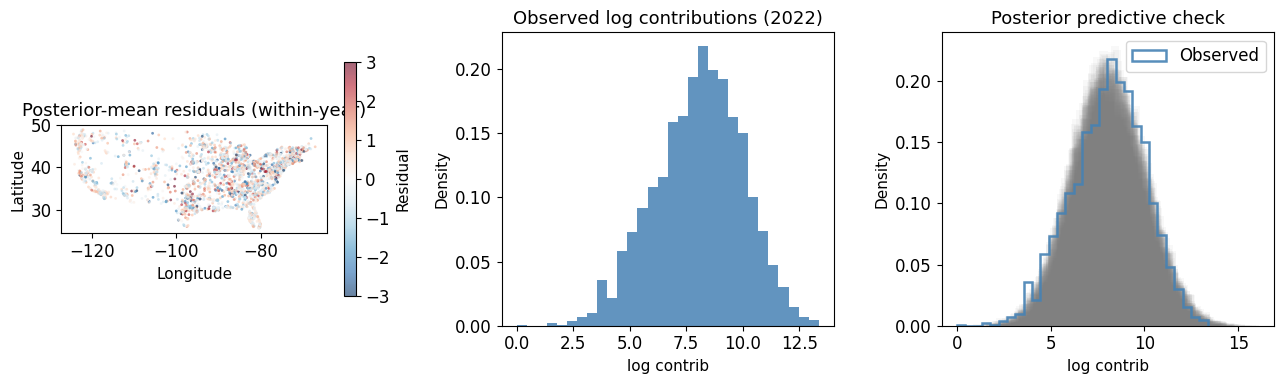

In [ ]:
# ── Posterior predictive check — within-year linear model ─────────────────────
# Three panels: residual map | observed histogram | PPC overlay

post = idata_wy_linear.posterior
beta_draws = post['beta'].stack(sample=('chain', 'draw')).values.T   # (S, p)
tau2_draws = post['tau2'].stack(sample=('chain', 'draw')).values     # (S,)

x_raw    = test_df[list(COVARIATES)].astype(float).to_numpy()
x_scaled = (x_raw - wy_linear_data.x_means) / wy_linear_data.x_sds
if wy_linear_data.state_names:
    dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
        columns=wy_linear_data.state_names, fill_value=0.0
    ).to_numpy()
    X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
else:
    X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])

y_obs      = test_df['log_contrib_2022'].astype(float).to_numpy()
beta_pm    = beta_draws.mean(axis=0)
resid      = y_obs - (X_test @ beta_pm)

rng   = np.random.default_rng(305)
n_ppc = 200
idx   = rng.choice(beta_draws.shape[0], size=n_ppc, replace=False)
mu_rep    = beta_draws[idx] @ X_test.T                               # (n_ppc, n_test)
sigma_rep = np.sqrt(tau2_draws[idx])[:, None]
y_rep     = rng.normal(mu_rep, sigma_rep)                            # (n_ppc, n_test)

plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 11})
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: residual map
ax = axes[0]
sc = ax.scatter(test_df['lon'], test_df['lat'],
                c=resid, cmap='RdBu_r', vmin=-3, vmax=3,
                s=4, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, shrink=0.8, label='Residual')
ax.set_title('Posterior-mean residuals (within-year)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')

# Panel 2: observed histogram
ax = axes[1]
ax.hist(y_obs, bins=30, color='steelblue', alpha=0.85, density=True)
ax.set_title('Observed log contributions (2022)')
ax.set_xlabel('log contrib'); ax.set_ylabel('Density')

# Panel 3: PPC overlay
ax = axes[2]
for i in range(min(50, n_ppc)):
    ax.hist(y_rep[i], bins=30, density=True, alpha=0.05,
            color='gray', histtype='stepfilled')
ax.hist(y_obs, bins=30, density=True, alpha=0.9, color='steelblue',
        histtype='step', linewidth=1.8, label='Observed')
ax.set_title('Posterior predictive check')
ax.set_xlabel('log contrib'); ax.set_ylabel('Density')
ax.legend()

plt.rcParams.update({
    "font.size":        14,   # base size — scales most things
    "axes.titlesize":   16,   # chart title
    "axes.labelsize":   14,   # x/y axis labels
    "xtick.labelsize":  12,   # x tick labels (the model names)
    "ytick.labelsize":  12,   # y tick values
    "legend.fontsize":  12,   # T0/T1/T2/T3 legend
})

plt.tight_layout()
plt.savefig('posterior_check_linear.pdf', bbox_inches='tight')
plt.show()

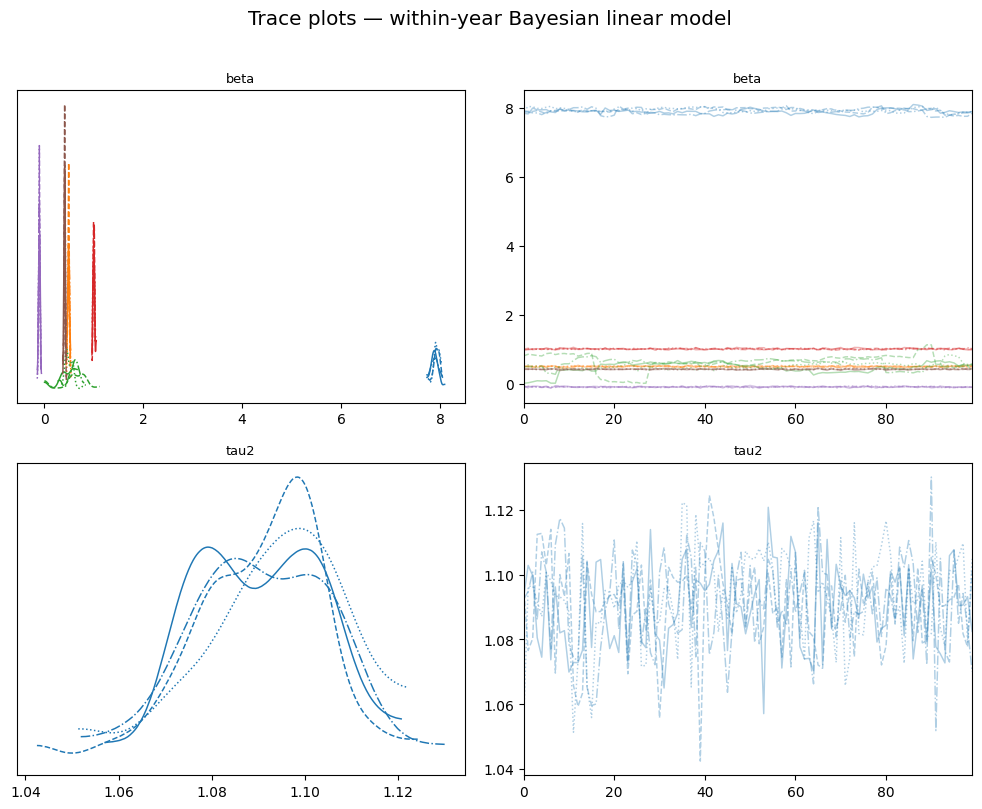

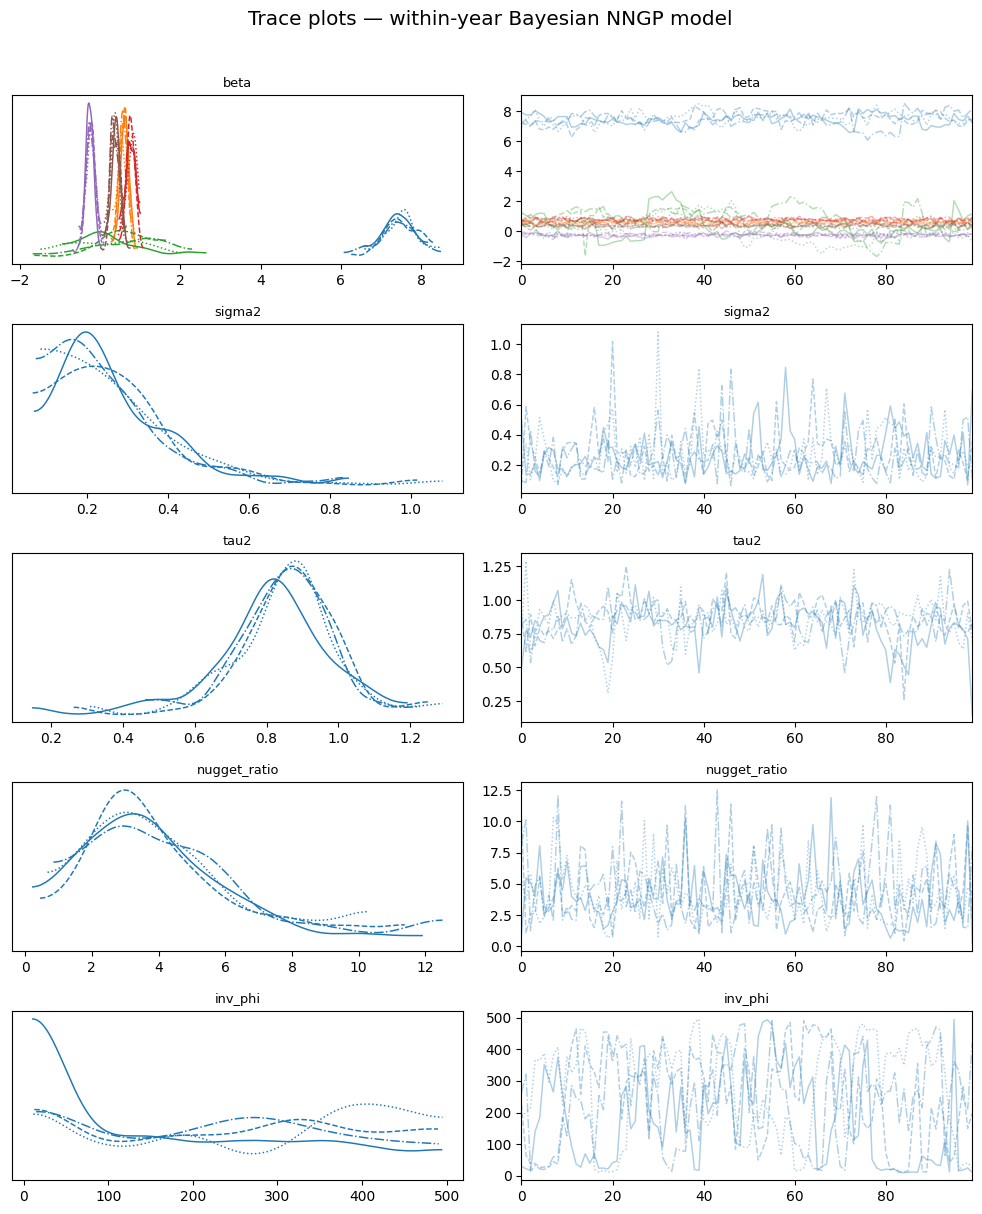

In [ ]:
# ── Inference diagnostics ──────────────────────────────────────────────────────
# Trace + marginal posterior plots for key parameters in both models.
# Shows: intercept + 5 continuous covariates + noise/spatial parameters.

def beta_var_and_coords(idata):
    """Return (var_name, coords_dict) for the first 6 beta entries (intercept + 5 covariates)."""
    post = idata.posterior
    if 'beta_cont' in post:
        n = min(6, post['beta_cont'].sizes['beta_cont_dim_0'])
        return 'beta_cont', {'beta_cont_dim_0': list(range(n))}
    else:
        # legacy: single 'beta' variable
        n = min(6, post['beta'].sizes['beta_dim_0'])
        return 'beta', {'beta_dim_0': list(range(n))}

# --- Within-year linear ---
bvar, bcoords = beta_var_and_coords(idata_wy_linear)
az.plot_trace(
    idata_wy_linear,
    var_names=[bvar, 'tau2'],
    coords=bcoords,
    compact=True,
    figsize=(10, 8),
)

plt.rcParams.update({
    "font.size":        14,   # base size — scales most things
    "axes.titlesize":   16,   # chart title
    "axes.labelsize":   14,   # x/y axis labels
    "xtick.labelsize":  12,   # x tick labels (the model names)
    "ytick.labelsize":  12,   # y tick values
    "legend.fontsize":  12,   # T0/T1/T2/T3 legend
})

# plt.suptitle('Trace plots — within-year Bayesian linear model', y=1.01)
plt.tight_layout()
plt.savefig('trace_linear_wy.pdf', bbox_inches='tight')
plt.show()

# --- Within-year NNGP ---
bvar, bcoords = beta_var_and_coords(idata_wy_spatial)
az.plot_trace(
    idata_wy_spatial,
    var_names=[bvar, 'sigma2', 'tau2', 'nugget_ratio', 'inv_phi'],
    coords=bcoords,
    compact=True,
    figsize=(10, 12),
)
# plt.suptitle('Trace plots — within-year Bayesian NNGP model', y=1.01)
plt.tight_layout()
plt.savefig('trace_spatial_wy.pdf', bbox_inches='tight')
plt.show()